# Notebook 04: Model 2 — Anomaly Detection

**Project:** MAP Dryer AI  
**Purpose:** build an unsupervised monitoring model that identifies unusual combinations of MAP dryer operating conditions.

This notebook begins the anomaly-detection workflow. The first three tasks define the modelling objective, load the processed feature table produced by Notebook 02, and select candidate process features.

## 1. Define the anomaly-detection objective

The objective is to detect **multivariate operating conditions that differ materially from normal MAP dryer behaviour**. Each timestamped process record is one observation. The future detector will learn the normal operating envelope from an earlier chronological reference period, assign every new record a continuous anomaly score, and raise a review flag when that score crosses a validated threshold.

The intended users are process operators and engineers investigating developing equipment, control, or process problems. A flag means that the combination of measurements is unusual; it does **not** by itself identify the root cause, prove that product is off specification, or replace existing safety alarms.

### Success criteria

- Detect unusual multivariate operating states early enough for operator review.
- Keep the anomaly score and alarm decision reproducible for each timestamp.
- Limit nuisance alarms through validation, threshold selection, and persistence logic.
- Provide contributing-variable diagnostics so engineers can investigate each flag.
- Use only variables confirmed to be available at inference time; the formal availability and leakage audit is Task 4.

## Setup: import libraries and locate the project root

Load the libraries needed for data handling and later anomaly modelling. The project-root pattern is the same as in the preceding notebooks, so the notebook runs from either the repository root or the `notebooks/` directory.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.project_paths import find_project_root

PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "04_Model2_Anomaly"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the processed dryer dataset

Read the processed feature table created in Notebook 02 and parse its temporal columns. This uses the same data path and loading code as Notebook 03.

In [2]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_processed_2.csv"

dryerMAP_model = pd.read_csv(
    DATA_PATH,
    parse_dates=["date", "timestamp"]
)

dryerMAP_model["time"] = dryerMAP_model["time"].astype(str)

display(dryerMAP_model.head())
dryerMAP_model.info()

,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,2026-04-23,01:00:00,139.0,23.2,23.62,10.00,47.7,20.96,-1.18,4.69,1270.0,1.023,41.0,0.075,2026-04-23 01:00:00,98.0,91.3,2.362000,651.910,2913.440
1,2026-04-23,03:00:00,139.7,21.4,24.32,10.20,46.6,20.29,-0.63,4.78,1236.0,1.028,43.7,0.087,2026-04-23 03:00:00,96.0,93.1,2.384314,667.766,2834.513
2,2026-04-23,05:00:00,140.1,18.9,23.80,10.25,47.3,20.36,-1.08,4.81,1272.0,1.034,45.7,0.072,2026-04-23 05:00:00,94.4,92.8,2.321951,673.881,2852.436
3,2026-04-23,07:00:00,139.7,18.5,23.35,10.27,48.1,20.25,-0.65,4.77,1238.0,1.033,45.2,0.094,2026-04-23 07:00:00,94.5,91.6,2.273612,666.369,2828.925
4,2026-04-23,09:00:00,139.8,19.0,23.44,10.35,46.5,20.99,-1.10,4.84,1267.0,1.025,42.9,0.084,2026-04-23 09:00:00,96.9,93.3,2.264734,676.632,2934.402


<class 'pandas.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1080 non-null   datetime64[us]
 1   time                       1080 non-null   str           
 2   dryer_air_temperature      1080 non-null   float64       
 3   cooler_air_temperature     1080 non-null   float64       
 4   air_flow_rate              1080 non-null   float64       
 5   wet_product_feed_rate      1080 non-null   float64       
 6   product_inlet_temperature  1080 non-null   float64       
 7   residence_time             1080 non-null   float64       
 8   vacuum                     1080 non-null   float64       
 9   steam_pressure             1080 non-null   float64       
 10  fan_speed                  1080 non-null   float64       
 11  product_density            1080 non-null   float64       
 12  final_product_tem

## 3. Select candidate anomaly features

Select direct process measurements and the engineered process indicators created in Notebook 02. The list is explicit so every detector input remains auditable. It intentionally focuses on the dryer operating state rather than identifiers or timestamps. Task 4 will formally confirm real-time availability and remove any remaining leakage risk before model training.

In [3]:
DIRECT_PROCESS_FEATURES = [
    "dryer_air_temperature",
    "cooler_air_temperature",
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed",
    "product_density",
    "final_product_temp",
]

ENGINEERED_PROCESS_FEATURES = [
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "steam_temp_interaction",
    "heating_index",
]

ANOMALY_FEATURES = DIRECT_PROCESS_FEATURES + ENGINEERED_PROCESS_FEATURES

missing_features = [
    feature for feature in ANOMALY_FEATURES if feature not in dryerMAP_model.columns
]
if missing_features:
    raise KeyError(f"Selected anomaly features are missing: {missing_features}")

anomaly_feature_catalog = pd.DataFrame(
    {
        "Feature": ANOMALY_FEATURES,
        "Feature group": (
            ["Direct process measurement"] * len(DIRECT_PROCESS_FEATURES)
            + ["Engineered process indicator"] * len(ENGINEERED_PROCESS_FEATURES)
        ),
    }
)

X_anomaly_candidates = dryerMAP_model[ANOMALY_FEATURES].copy()

display(anomaly_feature_catalog)
print(f"Selected candidate features: {len(ANOMALY_FEATURES)}")
print(f"Candidate feature matrix shape: {X_anomaly_candidates.shape}")

,Feature,Feature group
0,dryer_air_temperature,Direct process measurement
1,cooler_air_temperature,Direct process measurement
2,air_flow_rate,Direct process measurement
3,wet_product_feed_rate,Direct process measurement
4,product_inlet_temperature,Direct process measurement
5,residence_time,Direct process measurement
6,vacuum,Direct process measurement
7,steam_pressure,Direct process measurement
8,fan_speed,Direct process measurement
9,product_density,Direct process measurement


Selected candidate features: 16
Candidate feature matrix shape: (1080, 16)


## 4. Remove unavailable and leakage variables

Exclude administrative time fields from the detector inputs and reserve `timestamp` only for chronological ordering and reporting. Exclude `final_moisture_h₂o` because it is a delayed laboratory quality result rather than a real-time process signal. The retained direct measurements are documented PCS7 process variables, and every engineered feature is calculated only from those retained measurements.

In [4]:
EXCLUDED_COLUMNS = {
    "date": "Administrative calendar field; not a process-state measurement.",
    "time": "Administrative clock field; not a process-state measurement.",
    "timestamp": "Retained separately for ordering and reporting only.",
    "final_moisture_h₂o": (
        "Delayed laboratory quality result; unavailable for real-time process detection."
    ),
}

missing_excluded_columns = [
    column for column in EXCLUDED_COLUMNS if column not in dryerMAP_model.columns
]
if missing_excluded_columns:
    raise KeyError(f"Expected excluded columns are missing: {missing_excluded_columns}")

unreviewed_columns = sorted(
    set(dryerMAP_model.columns)
    - set(ANOMALY_FEATURES)
    - set(EXCLUDED_COLUMNS)
)
if unreviewed_columns:
    raise ValueError(f"Columns still require an availability audit: {unreviewed_columns}")

MODEL_FEATURES = [
    feature for feature in ANOMALY_FEATURES if feature not in EXCLUDED_COLUMNS
]
X_anomaly = dryerMAP_model[MODEL_FEATURES].copy()

if not X_anomaly.select_dtypes(exclude="number").empty:
    raise TypeError("All anomaly-model inputs must be numeric.")

availability_leakage_audit = pd.DataFrame(
    [
        {
            "Column": column,
            "Detector input": "No" if column in EXCLUDED_COLUMNS else "Yes",
            "Decision": (
                EXCLUDED_COLUMNS[column]
                if column in EXCLUDED_COLUMNS
                else "Retained real-time process measurement or derived process indicator."
            ),
        }
        for column in dryerMAP_model.columns
    ]
)

display(availability_leakage_audit)
print(f"Final model inputs after audit: {len(MODEL_FEATURES)}")
print("Excluded columns:", list(EXCLUDED_COLUMNS))

,Column,Detector input,Decision
0,date,No,Administrative calendar field; not a process-s...
1,time,No,Administrative clock field; not a process-stat...
2,dryer_air_temperature,Yes,Retained real-time process measurement or deri...
3,cooler_air_temperature,Yes,Retained real-time process measurement or deri...
4,air_flow_rate,Yes,Retained real-time process measurement or deri...
5,wet_product_feed_rate,Yes,Retained real-time process measurement or deri...
6,product_inlet_temperature,Yes,Retained real-time process measurement or deri...
7,residence_time,Yes,Retained real-time process measurement or deri...
8,vacuum,Yes,Retained real-time process measurement or deri...
9,steam_pressure,Yes,Retained real-time process measurement or deri...


Final model inputs after audit: 16
Excluded columns: ['date', 'time', 'timestamp', 'final_moisture_h₂o']


## PCS7 operating-limit configuration (provisional)

The values below are **prototype limits**, based on the observed dataset ranges and outer distributions so the hybrid workflow can be demonstrated. They are deliberately wider than a simple per-feature percentile rule to avoid classifying too many rows as critical when 11 limits are evaluated together. They are not approved PCS7 or safety limits and must be replaced before operational use. `LL` and `HH` represent critical low/high limits; `L` and `H` represent warning limits. Limits are evaluated in original engineering units before scaling.

In [5]:
# PROTOTYPE ONLY: replace these values with approved limits copied from PCS7.
PCS7_LIMIT_CONFIGURATION_MODE = (
    "PROTOTYPE: dataset-range demonstration; not approved for operations"
)
PCS7_FEATURE_LIMITS = {
    "dryer_air_temperature": {"LL": 136.5, "L": 137.1, "H": 141.6, "HH": 142.5, "unit": "°C"},
    "cooler_air_temperature": {"LL": 18.0, "L": 18.5, "H": 31.9, "HH": 33.0, "unit": "°C"},
    "air_flow_rate": {"LL": 21.2, "L": 22.0, "H": 25.8, "HH": 26.5, "unit": None},
    "wet_product_feed_rate": {"LL": 9.2, "L": 9.37, "H": 10.92, "HH": 11.1, "unit": None},
    "product_inlet_temperature": {"LL": 43.5, "L": 44.4, "H": 51.2, "HH": 51.7, "unit": "°C"},
    "residence_time": {"LL": 18.6, "L": 19.0, "H": 21.94, "HH": 22.5, "unit": None},
    "vacuum": {"LL": -2.2, "L": -1.87, "H": -0.45, "HH": -0.4, "unit": None},
    "steam_pressure": {"LL": 4.3, "L": 4.43, "H": 5.16, "HH": 5.25, "unit": None},
    "fan_speed": {"LL": 1160.0, "L": 1193.0, "H": 1344.0, "HH": 1380.0, "unit": None},
    "product_density": {"LL": 1.008, "L": 1.014, "H": 1.039, "HH": 1.042, "unit": None},
    "final_product_temp": {"LL": 36.0, "L": 37.7, "H": 48.1, "HH": 49.0, "unit": "°C"},
}

LIMIT_ORDER = ["LL", "L", "H", "HH"]
unexpected_limit_features = sorted(
    set(PCS7_FEATURE_LIMITS) - set(DIRECT_PROCESS_FEATURES)
)
if unexpected_limit_features:
    raise KeyError(
        f"PCS7 limits contain unapproved model features: {unexpected_limit_features}"
    )

limit_configuration_rows = []
for feature in DIRECT_PROCESS_FEATURES:
    feature_limits = PCS7_FEATURE_LIMITS[feature]
    configured_pairs = [
        (limit_name, feature_limits[limit_name])
        for limit_name in LIMIT_ORDER
        if feature_limits[limit_name] is not None
    ]
    configured_values = [value for _, value in configured_pairs]
    if configured_values != sorted(configured_values):
        raise ValueError(
            f"PCS7 limits for {feature} must satisfy LL <= L <= H <= HH."
        )
    limit_configuration_rows.append(
        {
            "Feature": feature,
            "LL": feature_limits["LL"],
            "L": feature_limits["L"],
            "H": feature_limits["H"],
            "HH": feature_limits["HH"],
            "Unit": feature_limits["unit"],
            "Configured limits": len(configured_pairs),
        }
    )

pcs7_limit_configuration = pd.DataFrame(limit_configuration_rows).set_index("Feature")
CONFIGURED_PCS7_LIMIT_COUNT = int(
    pcs7_limit_configuration["Configured limits"].sum()
)
CONFIGURED_PCS7_FEATURE_COUNT = int(
    (pcs7_limit_configuration["Configured limits"] > 0).sum()
)


def evaluate_pcs7_limits(process_data, feature_limits):
    limit_results = process_data[["timestamp"]].reset_index(drop=True).copy()
    state_columns = []

    for feature in DIRECT_PROCESS_FEATURES:
        limits = feature_limits[feature]
        values = process_data[feature].reset_index(drop=True)
        state_column = f"{feature} PCS7 state"
        state_columns.append(state_column)

        if all(limits[name] is None for name in LIMIT_ORDER):
            state = np.full(len(values), "Not configured", dtype=object)
        else:
            state = np.full(
                len(values), "Within configured limits", dtype=object
            )
            if limits["L"] is not None:
                state[values < limits["L"]] = "L warning"
            if limits["H"] is not None:
                state[values > limits["H"]] = "H warning"
            if limits["LL"] is not None:
                state[values <= limits["LL"]] = "LL critical"
            if limits["HH"] is not None:
                state[values >= limits["HH"]] = "HH critical"

        limit_results[state_column] = state

    warning_mask = limit_results[state_columns].isin(["L warning", "H warning"])
    critical_mask = limit_results[state_columns].isin(
        ["LL critical", "HH critical"]
    )
    limit_results["PCS7 warning count"] = warning_mask.sum(axis=1)
    limit_results["PCS7 critical count"] = critical_mask.sum(axis=1)
    limit_results["PCS7 breach count"] = (
        limit_results["PCS7 warning count"]
        + limit_results["PCS7 critical count"]
    )
    limit_results["PCS7 rule breach"] = limit_results["PCS7 breach count"] > 0

    breached_feature_labels = []
    for row_index in range(len(limit_results)):
        row_breaches = []
        for feature, state_column in zip(DIRECT_PROCESS_FEATURES, state_columns):
            feature_state = limit_results.at[row_index, state_column]
            if feature_state not in ["Not configured", "Within configured limits"]:
                row_breaches.append(f"{feature}: {feature_state}")
        breached_feature_labels.append("; ".join(row_breaches))
    limit_results["PCS7 breached features"] = breached_feature_labels

    if CONFIGURED_PCS7_LIMIT_COUNT == 0:
        limit_results["PCS7 limit status"] = "Not configured"
    else:
        limit_results["PCS7 limit status"] = np.select(
            [
                limit_results["PCS7 critical count"] > 0,
                limit_results["PCS7 warning count"] > 0,
            ],
            ["Critical", "Warning"],
            default="Within configured limits",
        )
    return limit_results


pcs7_limit_results = evaluate_pcs7_limits(dryerMAP_model, PCS7_FEATURE_LIMITS)
display(pcs7_limit_configuration)
print("PCS7 limit mode:", PCS7_LIMIT_CONFIGURATION_MODE)
print(
    f"PCS7 configuration coverage: {CONFIGURED_PCS7_FEATURE_COUNT}/"
    f"{len(DIRECT_PROCESS_FEATURES)} features, "
    f"{CONFIGURED_PCS7_LIMIT_COUNT} individual limits."
)
if CONFIGURED_PCS7_LIMIT_COUNT == 0:
    print(
        "PCS7 rule alarms are disabled until approved limits replace the None values."
    )

,LL,L,H,HH,Unit,Configured limits
Feature,,,,,,
dryer_air_temperature,136.500,137.100,141.600,142.500,°C,4
cooler_air_temperature,18.000,18.500,31.900,33.000,°C,4
air_flow_rate,21.200,22.000,25.800,26.500,NaN,4
wet_product_feed_rate,9.200,9.370,10.920,11.100,NaN,4
product_inlet_temperature,43.500,44.400,51.200,51.700,°C,4
residence_time,18.600,19.000,21.940,22.500,NaN,4
vacuum,-2.200,-1.870,-0.450,-0.400,NaN,4
steam_pressure,4.300,4.430,5.160,5.250,NaN,4
fan_speed,1160.000,1193.000,1344.000,1380.000,NaN,4


PCS7 limit mode: PROTOTYPE: dataset-range demonstration; not approved for operations
PCS7 configuration coverage: 11/11 features, 44 individual limits.


## 5. Inspect retained feature distributions

Review descriptive statistics and univariate distributions before defining the normal reference period. These plots reveal scale differences, skew, long tails, and possible data-quality issues; unusual tails are not automatically treated as anomalies at this stage because operating context still matters.

,count,missing values,non-finite values,mean,std,min,25%,50%,75%,max,skewness
dryer_air_temperature,1080.0,0,0,139.3990,1.1026,136.3000,138.5000,139.4000,140.2000,142.8000,0.0088
cooler_air_temperature,1080.0,0,0,24.2626,3.4003,18.5000,21.5000,24.3000,26.7000,33.3000,0.1338
air_flow_rate,1080.0,0,0,23.8650,0.8460,21.0100,23.2500,23.8500,24.4325,27.0000,0.1207
wet_product_feed_rate,1080.0,0,0,10.1518,0.4017,9.1600,9.8200,10.1500,10.4700,11.1800,0.0151
product_inlet_temperature,1080.0,0,0,47.7766,1.5305,43.2000,46.7000,47.7000,48.8000,51.9000,0.0269
residence_time,1080.0,0,0,20.5669,0.6563,18.4500,20.1100,20.5900,21.0025,22.6900,-0.1313
vacuum,1080.0,0,0,-0.9975,0.3451,-2.3000,-1.2300,-0.9800,-0.7200,-0.4500,-0.3685
steam_pressure,1080.0,0,0,4.7890,0.1630,4.2700,4.6800,4.7900,4.9000,5.3000,0.0005
fan_speed,1080.0,0,0,1264.7259,32.4984,1148.0000,1241.0000,1263.5000,1288.0000,1392.0000,0.1195
product_density,1080.0,0,0,1.0265,0.0052,1.0070,1.0230,1.0260,1.0300,1.0410,-0.0465


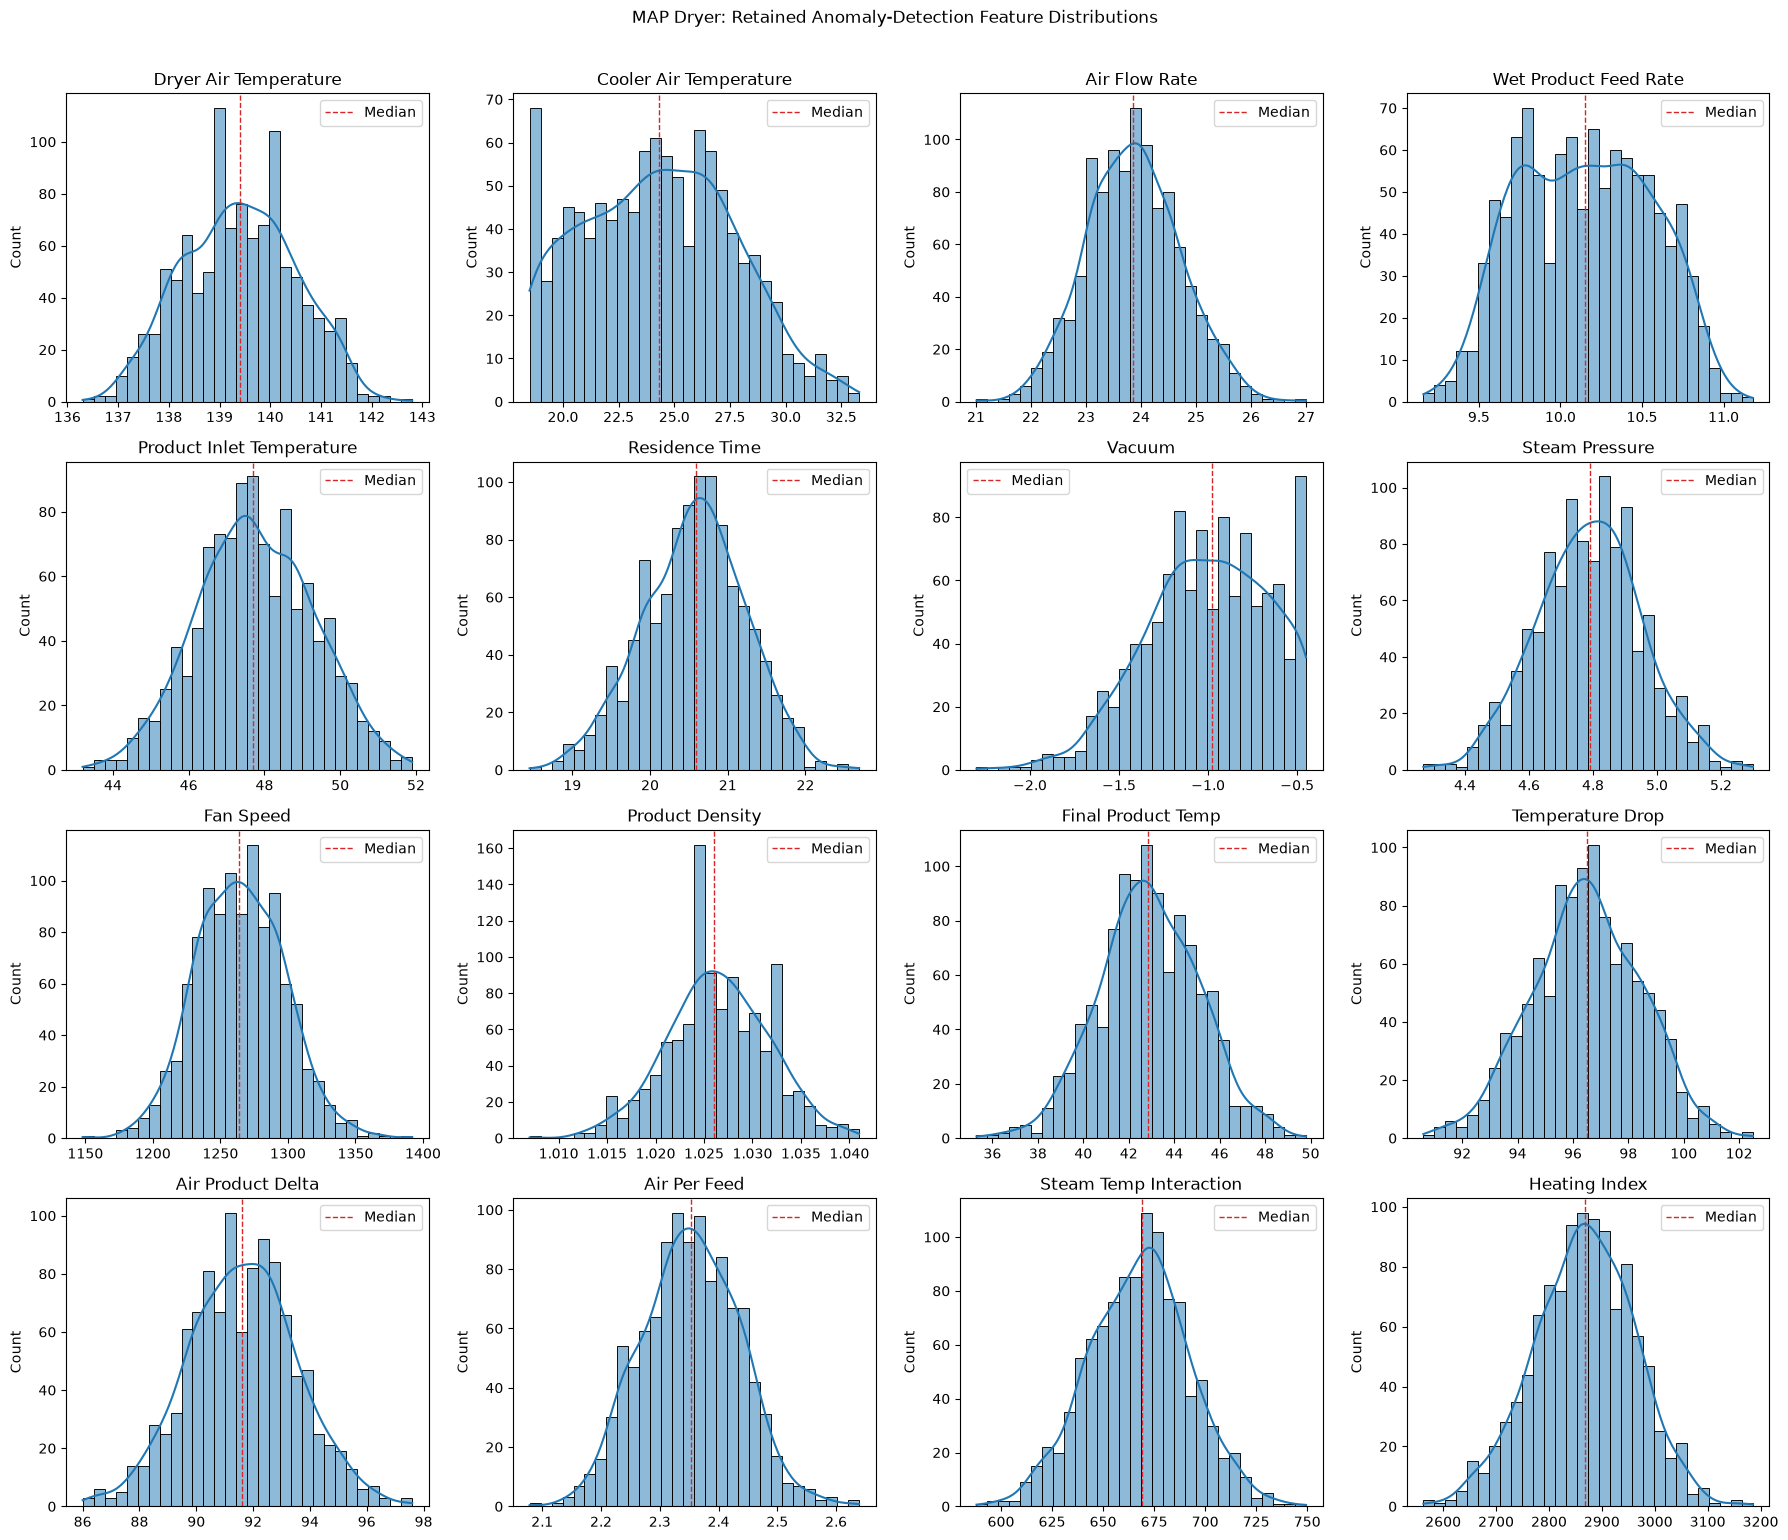

In [6]:
distribution_summary = X_anomaly.describe().T
distribution_summary["missing values"] = X_anomaly.isna().sum()
distribution_summary["non-finite values"] = (
    ~np.isfinite(X_anomaly)
).sum()
distribution_summary["skewness"] = X_anomaly.skew()
distribution_summary = distribution_summary[
    [
        "count",
        "missing values",
        "non-finite values",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "skewness",
    ]
]
display(distribution_summary.round(4))

n_columns = 4
n_rows = int(np.ceil(len(MODEL_FEATURES) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(18, 3.8 * n_rows))
axes = np.asarray(axes).reshape(-1)

for axis, feature in zip(axes, MODEL_FEATURES):
    sns.histplot(
        X_anomaly[feature],
        bins=30,
        kde=True,
        color="tab:blue",
        ax=axis,
    )
    axis.axvline(
        X_anomaly[feature].median(),
        color="tab:red",
        linestyle="--",
        linewidth=1,
        label="Median",
    )
    axis.set_title(feature.replace("_", " " ).title())
    axis.set_xlabel("")
    axis.legend()

for axis in axes[len(MODEL_FEATURES):]:
    axis.set_visible(False)

fig.suptitle("MAP Dryer: Retained Anomaly-Detection Feature Distributions", y=1.01)
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_retained_feature_distributions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 6. Create chronological train, validation, and test sets

Sort records by timestamp and allocate the earliest 60% to training, the next 20% to validation, and the most recent 20% to testing. No rows are shuffled. This preserves temporal order, prevents future observations from entering the training period, and leaves two later periods for threshold selection and final evaluation.

In [7]:
TRAIN_FRACTION = 0.60
VALIDATION_FRACTION = 0.20

ordered_anomaly_data = (
    dryerMAP_model[["timestamp", *MODEL_FEATURES]]
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

if ordered_anomaly_data["timestamp"].isna().any():
    raise ValueError("Chronological splitting requires complete timestamps.")
if ordered_anomaly_data["timestamp"].duplicated().any():
    raise ValueError("Chronological splitting requires unique timestamps.")

n_observations = len(ordered_anomaly_data)
train_end = int(n_observations * TRAIN_FRACTION)
validation_end = train_end + int(n_observations * VALIDATION_FRACTION)

train_data = ordered_anomaly_data.iloc[:train_end].copy()
validation_data = ordered_anomaly_data.iloc[train_end:validation_end].copy()
test_data = ordered_anomaly_data.iloc[validation_end:].copy()

X_train = train_data[MODEL_FEATURES].copy()
X_validation = validation_data[MODEL_FEATURES].copy()
X_test = test_data[MODEL_FEATURES].copy()

train_timestamps = train_data["timestamp"].copy()
validation_timestamps = validation_data["timestamp"].copy()
test_timestamps = test_data["timestamp"].copy()

if not (
    train_timestamps.max() < validation_timestamps.min()
    and validation_timestamps.max() < test_timestamps.min()
):
    raise AssertionError("The chronological split boundaries overlap.")
if len(X_train) + len(X_validation) + len(X_test) != n_observations:
    raise AssertionError("The chronological split lost or duplicated observations.")

split_summary = pd.DataFrame(
    {
        "Rows": [len(train_data), len(validation_data), len(test_data)],
        "Share (%)": [
            100 * len(train_data) / n_observations,
            100 * len(validation_data) / n_observations,
            100 * len(test_data) / n_observations,
        ],
        "Start timestamp": [
            train_timestamps.min(),
            validation_timestamps.min(),
            test_timestamps.min(),
        ],
        "End timestamp": [
            train_timestamps.max(),
            validation_timestamps.max(),
            test_timestamps.max(),
        ],
    },
    index=["Training", "Validation", "Testing"],
)

display(split_summary.round({"Share (%)": 2}))

,Rows,Share (%),Start timestamp,End timestamp
Training,648,60.0,2026-04-23 01:00:00,2026-06-15 23:00:00
Validation,216,20.0,2026-06-16 01:00:00,2026-07-03 23:00:00
Testing,216,20.0,2026-07-04 01:00:00,2026-07-21 23:00:00


## 7. Define the normal reference training data

No confirmed fault-event labels are available in the processed dataset. Therefore, use the earliest chronological training period as the provisional representation of normal operation after enforcing data-quality checks and excluding any rows that breach configured PCS7 limits. While the limit configuration remains empty, no rows are removed by PCS7 rules. Do not remove other statistically extreme but valid observations at this stage, because doing so would artificially narrow the operating envelope. Isolation Forest is designed to tolerate a limited number of unusual training observations, and the operational threshold will be selected separately using validation data.

This assumption should be revisited when operator logs, maintenance records, or confirmed abnormal operating windows become available.

In [8]:
finite_training_rows = pd.Series(
    np.isfinite(X_train).all(axis=1),
    index=X_train.index,
    name="finite_values",
)
complete_training_rows = X_train.notna().all(axis=1)
training_pcs7_status = (
    train_data[["timestamp"]]
    .merge(
        pcs7_limit_results[
            ["timestamp", "PCS7 rule breach", "PCS7 limit status"]
        ],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .set_axis(X_train.index)
)
pcs7_normal_rows = ~training_pcs7_status["PCS7 rule breach"]
normal_reference_mask = (
    finite_training_rows & complete_training_rows & pcs7_normal_rows
)

X_normal_reference = X_train.loc[normal_reference_mask].copy()
normal_reference_timestamps = train_timestamps.loc[normal_reference_mask].copy()

if X_normal_reference.empty:
    raise ValueError("No valid rows remain for the normal reference period.")
if list(X_normal_reference.columns) != MODEL_FEATURES:
    raise AssertionError("Normal reference features do not match MODEL_FEATURES.")

normal_reference_summary = pd.DataFrame(
    {
        "Rows": [len(X_train), len(X_normal_reference)],
        "Share of training (%)": [
            100.0,
            100 * len(X_normal_reference) / len(X_train),
        ],
        "Start timestamp": [
            train_timestamps.min(),
            normal_reference_timestamps.min(),
        ],
        "End timestamp": [
            train_timestamps.max(),
            normal_reference_timestamps.max(),
        ],
    },
    index=["Chronological training period", "Normal reference after quality checks"],
)

display(normal_reference_summary.round({"Share of training (%)": 2}))
print(
    "Rows removed by missing/non-finite checks:",
    int((~(finite_training_rows & complete_training_rows)).sum()),
)
print("Rows removed by configured PCS7 limits:", int((~pcs7_normal_rows).sum()))

,Rows,Share of training (%),Start timestamp,End timestamp
Chronological training period,648,100.00,2026-04-23 01:00:00,2026-06-15 23:00:00
Normal reference after quality checks,552,85.19,2026-04-23 01:00:00,2026-06-15 23:00:00


Rows removed by missing/non-finite checks: 0
Rows removed by configured PCS7 limits: 96


## 8. Scale features

Fit a standard scaler only on the normal reference data, then apply the learned transformation to validation and test data without refitting. Isolation Forest does not strictly require standardized units, but a shared scaled representation supports later detector comparison and contributing-variable diagnostics while preventing future-period leakage.

In [9]:
from sklearn.preprocessing import StandardScaler

anomaly_scaler = StandardScaler()

X_normal_reference_scaled = pd.DataFrame(
    anomaly_scaler.fit_transform(X_normal_reference),
    columns=MODEL_FEATURES,
    index=X_normal_reference.index,
)
X_train_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_train),
    columns=MODEL_FEATURES,
    index=X_train.index,
)
X_validation_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_validation),
    columns=MODEL_FEATURES,
    index=X_validation.index,
)
X_test_scaled = pd.DataFrame(
    anomaly_scaler.transform(X_test),
    columns=MODEL_FEATURES,
    index=X_test.index,
)

scaling_summary = pd.DataFrame(
    {
        "Reference raw mean": X_normal_reference.mean(),
        "Reference raw std": X_normal_reference.std(ddof=0),
        "Reference scaled mean": X_normal_reference_scaled.mean(),
        "Reference scaled std": X_normal_reference_scaled.std(ddof=0),
    }
)

if not np.allclose(X_normal_reference_scaled.mean(), 0.0, atol=1e-10):
    raise AssertionError("Scaled reference features are not centered at zero.")
if not np.allclose(X_normal_reference_scaled.std(ddof=0), 1.0, atol=1e-10):
    raise AssertionError("Scaled reference features do not have unit variance.")

display(scaling_summary.round(4))
print("Scaler fitted on normal reference rows only.")

,Reference raw mean,Reference raw std,Reference scaled mean,Reference scaled std
dryer_air_temperature,139.4627,1.0453,-0.0,1.0
cooler_air_temperature,23.3627,3.0286,-0.0,1.0
air_flow_rate,23.7889,0.7576,0.0,1.0
wet_product_feed_rate,10.1678,0.3760,0.0,1.0
product_inlet_temperature,47.6201,1.4188,0.0,1.0
residence_time,20.5479,0.6129,-0.0,1.0
vacuum,-0.9636,0.3185,-0.0,1.0
steam_pressure,4.7981,0.1530,-0.0,1.0
fan_speed,1261.8967,29.1113,0.0,1.0
product_density,1.0268,0.0049,-0.0,1.0


Scaler fitted on normal reference rows only.


## 9. Train Isolation Forest

Fit an Isolation Forest on the scaled normal reference period. The model uses 300 trees and a fixed random seed for reproducibility. `contamination="auto"` is retained during fitting because the operational anomaly threshold is deliberately deferred to Task 11; the estimator's built-in class labels are not used as final alarms.

In [10]:
from sklearn.ensemble import IsolationForest

isolation_forest_model = IsolationForest(
    n_estimators=300,
    max_samples="auto",
    contamination="auto",
    max_features=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)
isolation_forest_model.fit(X_normal_reference_scaled)

isolation_forest_training_summary = pd.Series(
    {
        "Training rows": len(X_normal_reference_scaled),
        "Features": X_normal_reference_scaled.shape[1],
        "Trees fitted": len(isolation_forest_model.estimators_),
        "Maximum samples per tree": isolation_forest_model.max_samples_,
        "Contamination setting": isolation_forest_model.contamination,
        "Random state": isolation_forest_model.random_state,
    },
    name="Isolation Forest",
)

display(isolation_forest_training_summary.to_frame())
print("Isolation Forest fitted; scoring and threshold selection remain separate.")

,Isolation Forest
Training rows,552
Features,16
Trees fitted,300
Maximum samples per tree,256
Contamination setting,auto
Random state,42


Isolation Forest fitted; scoring and threshold selection remain separate.


## 10. Generate anomaly scores

Generate a continuous score for every reference, validation, and test observation. Isolation Forest's native `score_samples` output becomes smaller as an observation becomes more unusual, so multiply it by -1 to create an intuitive anomaly score where **larger values indicate more anomalous operating conditions**. No threshold or alarm label is applied in this step.

In [11]:
def build_anomaly_score_table(split_name, timestamps, scaled_features):
    anomaly_scores = -isolation_forest_model.score_samples(
        scaled_features[MODEL_FEATURES]
    )
    return pd.DataFrame(
        {
            "timestamp": timestamps.to_numpy(),
            "Split": split_name,
            "Anomaly score": anomaly_scores,
        }
    )


anomaly_score_results = (
    pd.concat(
        [
            build_anomaly_score_table(
                "Reference",
                train_timestamps,
                X_train_scaled,
            ),
            build_anomaly_score_table(
                "Validation",
                validation_timestamps,
                X_validation_scaled,
            ),
            build_anomaly_score_table(
                "Testing",
                test_timestamps,
                X_test_scaled,
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

score_distribution_summary = (
    anomaly_score_results.groupby("Split", sort=False)["Anomaly score"]
    .describe(percentiles=[0.50, 0.95, 0.99])
    [["count", "mean", "std", "min", "50%", "95%", "99%", "max"]]
)

if anomaly_score_results["Anomaly score"].isna().any():
    raise ValueError("Anomaly scoring produced missing values.")

display(score_distribution_summary.round(5))
print("Score direction: higher values indicate more unusual observations.")

,count,mean,std,min,50%,95%,99%,max
Split,,,,,,,,
Reference,648.0,0.47228,0.03985,0.39725,0.46953,0.54500,0.57545,0.60869
Validation,216.0,0.47814,0.04386,0.39521,0.46937,0.55725,0.60469,0.62906
Testing,216.0,0.48248,0.04869,0.39859,0.47236,0.57174,0.62179,0.62927


Score direction: higher values indicate more unusual observations.


## 11. Define the anomaly threshold

Use the 99th percentile of validation anomaly scores as the raw candidate threshold. This treats the unlabeled validation period as mostly representative of acceptable operation and targets a low review rate while allowing for modest drift from the earlier reference period. The test scores are not used to choose the threshold. Because no confirmed anomaly labels are available, this is an explicit operating assumption rather than a proven optimum; Task 17 will tune it and Task 15 will add persistence before a flag becomes an alarm.

In [12]:
VALIDATION_THRESHOLD_QUANTILE = 0.99

validation_anomaly_scores = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Validation",
    "Anomaly score",
]
ANOMALY_THRESHOLD = float(
    validation_anomaly_scores.quantile(VALIDATION_THRESHOLD_QUANTILE)
)

anomaly_score_results["Raw anomaly flag"] = (
    anomaly_score_results["Anomaly score"] >= ANOMALY_THRESHOLD
)

threshold_evaluation = (
    anomaly_score_results.groupby("Split", sort=False)
    .agg(
        Observations=("Raw anomaly flag", "size"),
        Raw_anomaly_candidates=("Raw anomaly flag", "sum"),
        Minimum_score=("Anomaly score", "min"),
        Maximum_score=("Anomaly score", "max"),
    )
)
threshold_evaluation["Raw candidate rate (%)"] = (
    100
    * threshold_evaluation["Raw_anomaly_candidates"]
    / threshold_evaluation["Observations"]
)

display(threshold_evaluation.round(4))
print(
    f"Validation {VALIDATION_THRESHOLD_QUANTILE:.0%} threshold: "
    f"{ANOMALY_THRESHOLD:.5f}"
)

,Observations,Raw_anomaly_candidates,Minimum_score,Maximum_score,Raw candidate rate (%)
Split,,,,,
Reference,648,1,0.3973,0.6087,0.1543
Validation,216,3,0.3952,0.6291,1.3889
Testing,216,6,0.3986,0.6293,2.7778


Validation 99% threshold: 0.60469


## 12. Visualize anomalies through time

Plot the continuous anomaly score across the complete chronological record. Points above the validated threshold are highlighted as raw anomaly candidates. They are investigation candidates only—not persistent operator alarms—and the colors identify which observations belong to the reference, validation, and untouched test periods.

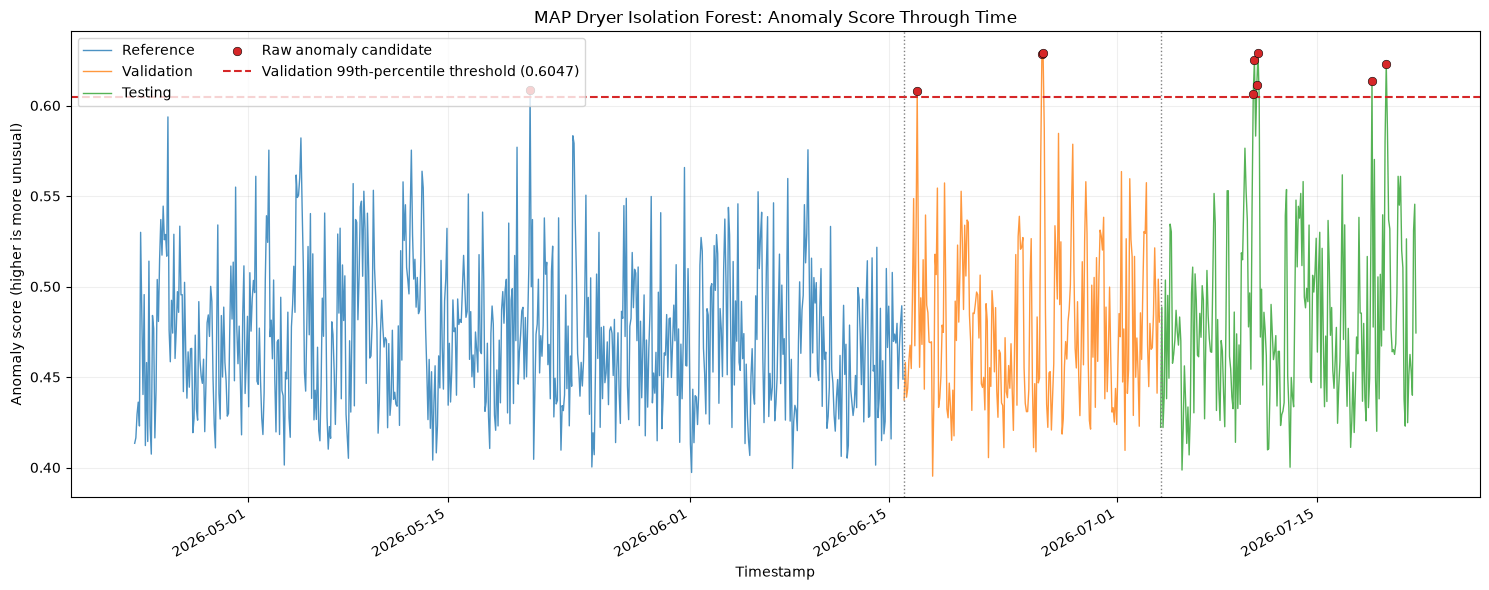

In [13]:
split_colors = {
    "Reference": "tab:blue",
    "Validation": "tab:orange",
    "Testing": "tab:green",
}

fig, axis = plt.subplots(figsize=(15, 6))
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axis.plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1.0,
        alpha=0.8,
        label=split_name,
    )

raw_anomaly_candidates = anomaly_score_results.loc[
    anomaly_score_results["Raw anomaly flag"]
]
axis.scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.4,
    s=38,
    zorder=4,
    label="Raw anomaly candidate",
)
axis.axhline(
    ANOMALY_THRESHOLD,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    label=f"Validation 99th-percentile threshold ({ANOMALY_THRESHOLD:.4f})",
)
axis.axvline(
    validation_timestamps.min(),
    color="grey",
    linestyle=":",
    linewidth=1,
)
axis.axvline(
    test_timestamps.min(),
    color="grey",
    linestyle=":",
    linewidth=1,
)
axis.set_title("MAP Dryer Isolation Forest: Anomaly Score Through Time")
axis.set_xlabel("Timestamp")
axis.set_ylabel("Anomaly score (higher is more unusual)")
axis.grid(alpha=0.2)
axis.legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "02_anomaly_scores_over_time.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 13. Inspect anomalous operating points

Join every raw anomaly candidate back to its unscaled operating measurements and rank the rows by anomaly score. This table supports engineering review of the actual process state while keeping the score, split, and timestamp attached to each observation.

In [14]:
anomalous_operating_points = (
    anomaly_score_results.loc[
        anomaly_score_results["Raw anomaly flag"],
        ["timestamp", "Split", "Anomaly score"],
    ]
    .merge(
        dryerMAP_model[["timestamp", *MODEL_FEATURES]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Anomaly score", ascending=False)
    .reset_index(drop=True)
)
anomalous_operating_points.insert(
    0, "Candidate rank", np.arange(1, len(anomalous_operating_points) + 1)
)

if anomalous_operating_points[MODEL_FEATURES].isna().any().any():
    raise ValueError("Anomaly candidates could not be matched to all process measurements.")

operating_point_rounding = {
    column: 4 for column in ["Anomaly score", *MODEL_FEATURES]
}
display(anomalous_operating_points.round(operating_point_rounding))
print(f"Raw anomaly candidates available for review: {len(anomalous_operating_points)}")

,Candidate rank,timestamp,Split,Anomaly score,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,temperature_drop,air_product_delta,air_per_feed,steam_temp_interaction,heating_index
0,1,2026-07-10 21:00:00,Testing,0.6293,137.3,32.8,25.28,10.57,50.5,19.57,-1.87,4.81,1340.0,1.021,36.0,101.3,86.8,2.3917,660.413,2686.961
1,2,2026-06-25 19:00:00,Validation,0.6291,139.5,32.5,26.16,10.35,51.8,19.61,-2.17,4.51,1370.0,1.035,41.6,97.9,87.7,2.5275,629.145,2735.595
2,3,2026-06-25 17:00:00,Validation,0.6286,138.9,31.5,25.59,10.52,50.5,19.21,-1.77,4.87,1337.0,1.021,38.2,100.7,88.4,2.4325,676.443,2668.269
3,4,2026-07-10 15:00:00,Testing,0.6252,137.8,30.0,25.89,10.76,48.9,19.21,-1.85,4.83,1336.0,1.022,36.9,100.9,88.9,2.4061,665.574,2647.138
4,5,2026-07-19 21:00:00,Testing,0.6232,137.3,31.1,25.15,10.61,50.9,20.09,-1.61,4.68,1319.0,1.015,38.0,99.3,86.4,2.3704,642.564,2758.357
5,6,2026-07-18 21:00:00,Testing,0.6138,137.8,31.2,25.36,10.66,48.5,20.17,-1.70,4.49,1335.0,1.023,37.7,100.1,89.3,2.3790,618.722,2779.426
6,7,2026-07-10 19:00:00,Testing,0.6115,136.9,33.3,27.00,10.74,49.1,19.78,-2.30,4.85,1392.0,1.024,38.7,98.2,87.8,2.5140,663.965,2707.882
7,8,2026-05-20 19:00:00,Reference,0.6087,137.3,28.8,25.51,10.22,47.5,20.07,-1.62,4.71,1322.0,1.007,36.5,100.8,89.8,2.4961,646.683,2755.611
8,9,2026-06-16 23:00:00,Validation,0.6077,138.0,29.0,24.85,9.45,48.8,21.55,-1.54,4.47,1307.0,1.029,39.6,98.4,89.2,2.6296,616.860,2973.900
9,10,2026-07-10 13:00:00,Testing,0.6065,137.8,27.8,26.08,10.86,48.5,18.94,-1.94,4.90,1350.0,1.019,38.4,99.4,89.3,2.4015,675.220,2609.932


Raw anomaly candidates available for review: 10


## 14. Diagnose contributing variables

Isolation Forest does not provide signed per-feature contributions for an individual prediction. Use each candidate's standardized distance from the normal-reference mean as a transparent diagnostic proxy: the largest absolute standardized deviations identify variables that deserve first inspection. These are investigation cues rather than causal explanations, and correlated engineered features may repeat the same underlying process deviation.

,Candidate rank,timestamp,Split,Anomaly score,Contributor rank,Feature,Signed standardized deviation,Absolute standardized deviation
0,1,2026-07-10 21:00:00,Testing,0.6293,1,final_product_temp,-3.6524,3.6524
1,1,2026-07-10 21:00:00,Testing,0.6293,2,cooler_air_temperature,3.1161,3.1161
2,1,2026-07-10 21:00:00,Testing,0.6293,3,temperature_drop,2.8615,2.8615
3,2,2026-06-25 19:00:00,Validation,0.6291,1,vacuum,-3.7872,3.7872
4,2,2026-06-25 19:00:00,Validation,0.6291,2,fan_speed,3.7135,3.7135
5,2,2026-06-25 19:00:00,Validation,0.6291,3,air_flow_rate,3.1297,3.1297
6,3,2026-06-25 17:00:00,Validation,0.6286,1,cooler_air_temperature,2.6868,2.6868
7,3,2026-06-25 17:00:00,Validation,0.6286,2,fan_speed,2.5799,2.5799
8,3,2026-06-25 17:00:00,Validation,0.6286,3,final_product_temp,-2.5447,2.5447
9,4,2026-07-10 15:00:00,Testing,0.6252,1,final_product_temp,-3.1992,3.1992


,Top_three_appearances,Mean_absolute_deviation,Maximum_absolute_deviation
Feature,,,
final_product_temp,6,3.0398,3.6524
fan_speed,5,3.2600,4.4692
vacuum,4,3.4576,4.1953
air_flow_rate,4,3.2914,4.2384
cooler_air_temperature,4,2.7364,3.1161
temperature_drop,2,2.7210,2.8615
product_density,1,4.0522,4.0522
air_per_feed,1,3.7030,3.7030
air_product_delta,1,3.0861,3.0861


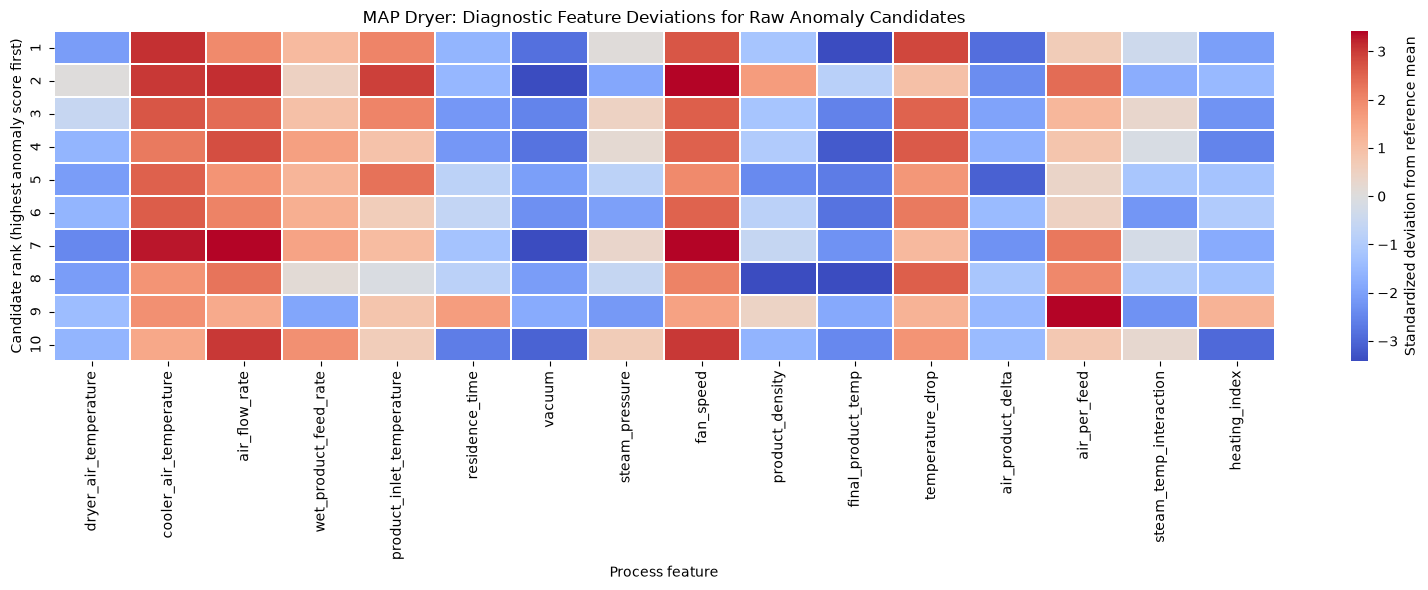

In [15]:
def build_scaled_feature_table(split_name, timestamps, scaled_features):
    split_table = scaled_features[MODEL_FEATURES].reset_index(drop=True).copy()
    split_table.insert(0, "Split", split_name)
    split_table.insert(0, "timestamp", timestamps.to_numpy())
    return split_table


scaled_feature_timeline = (
    pd.concat(
        [
            build_scaled_feature_table(
                "Reference", train_timestamps, X_train_scaled
            ),
            build_scaled_feature_table(
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_scaled_feature_table(
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

candidate_scaled_features = (
    anomalous_operating_points[
        ["Candidate rank", "timestamp", "Split", "Anomaly score"]
    ]
    .merge(
        scaled_feature_timeline[["timestamp", *MODEL_FEATURES]],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    .sort_values("Candidate rank")
    .reset_index(drop=True)
)

diagnostic_records = []
for _, candidate in candidate_scaled_features.iterrows():
    ordered_features = (
        candidate[MODEL_FEATURES].astype(float).abs().sort_values(ascending=False)
    )
    for contributor_rank, feature in enumerate(ordered_features.index[:3], start=1):
        signed_deviation = float(candidate[feature])
        diagnostic_records.append(
            {
                "Candidate rank": int(candidate["Candidate rank"]),
                "timestamp": candidate["timestamp"],
                "Split": candidate["Split"],
                "Anomaly score": candidate["Anomaly score"],
                "Contributor rank": contributor_rank,
                "Feature": feature,
                "Signed standardized deviation": signed_deviation,
                "Absolute standardized deviation": abs(signed_deviation),
            }
        )

contributing_variable_diagnostics = pd.DataFrame(diagnostic_records)
contributor_summary = (
    contributing_variable_diagnostics.groupby("Feature")
    .agg(
        Top_three_appearances=("Feature", "size"),
        Mean_absolute_deviation=("Absolute standardized deviation", "mean"),
        Maximum_absolute_deviation=("Absolute standardized deviation", "max"),
    )
    .sort_values(
        ["Top_three_appearances", "Mean_absolute_deviation"],
        ascending=False,
    )
)

diagnostic_rounding = {
    "Anomaly score": 4,
    "Signed standardized deviation": 4,
    "Absolute standardized deviation": 4,
}
display(contributing_variable_diagnostics.round(diagnostic_rounding))
display(contributor_summary.round(4))

candidate_heatmap = candidate_scaled_features.set_index("Candidate rank")[
    MODEL_FEATURES
]
heatmap_limit = max(3.0, float(np.nanpercentile(np.abs(candidate_heatmap), 95)))
plt.figure(figsize=(16, max(6, 0.45 * len(candidate_heatmap))))
sns.heatmap(
    candidate_heatmap,
    cmap="coolwarm",
    center=0,
    vmin=-heatmap_limit,
    vmax=heatmap_limit,
    linewidths=0.2,
    cbar_kws={"label": "Standardized deviation from reference mean"},
)
plt.title("MAP Dryer: Diagnostic Feature Deviations for Raw Anomaly Candidates")
plt.xlabel("Process feature")
plt.ylabel("Candidate rank (highest anomaly score first)")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "03_candidate_feature_deviation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 15. Add persistence and alarm logic

Reduce nuisance alarms by requiring at least two raw anomaly candidates within a rolling window of three observations. At the dataset's two-hour sampling interval, this evaluates the current observation and the preceding four hours. A persistent alarm remains active while the rolling condition is satisfied. This rule converts statistical candidates into operational alarm episodes without changing their underlying anomaly scores.

,Split,Alarm start,Alarm end,Alarm observations,Raw candidates while active,Maximum anomaly score
Alarm episode,,,,,,
1,Validation,2026-06-25 19:00:00,2026-06-25 21:00:00,2,1,0.62906
2,Testing,2026-07-10 15:00:00,2026-07-10 23:00:00,5,3,0.62927


,Observations
Combined alarm state,
Normal within configured PCS7 limits,924
Warning: PCS7 limit,122
Critical: PCS7 limit,23
Review: raw ML candidate,4
Critical: PCS7 limit + persistent ML anomaly,3
High: PCS7 warning + persistent ML anomaly,3
Advisory: persistent ML anomaly,1


Persistence rule: 2 of 3 observations; sample interval = 0 days 02:00:00.


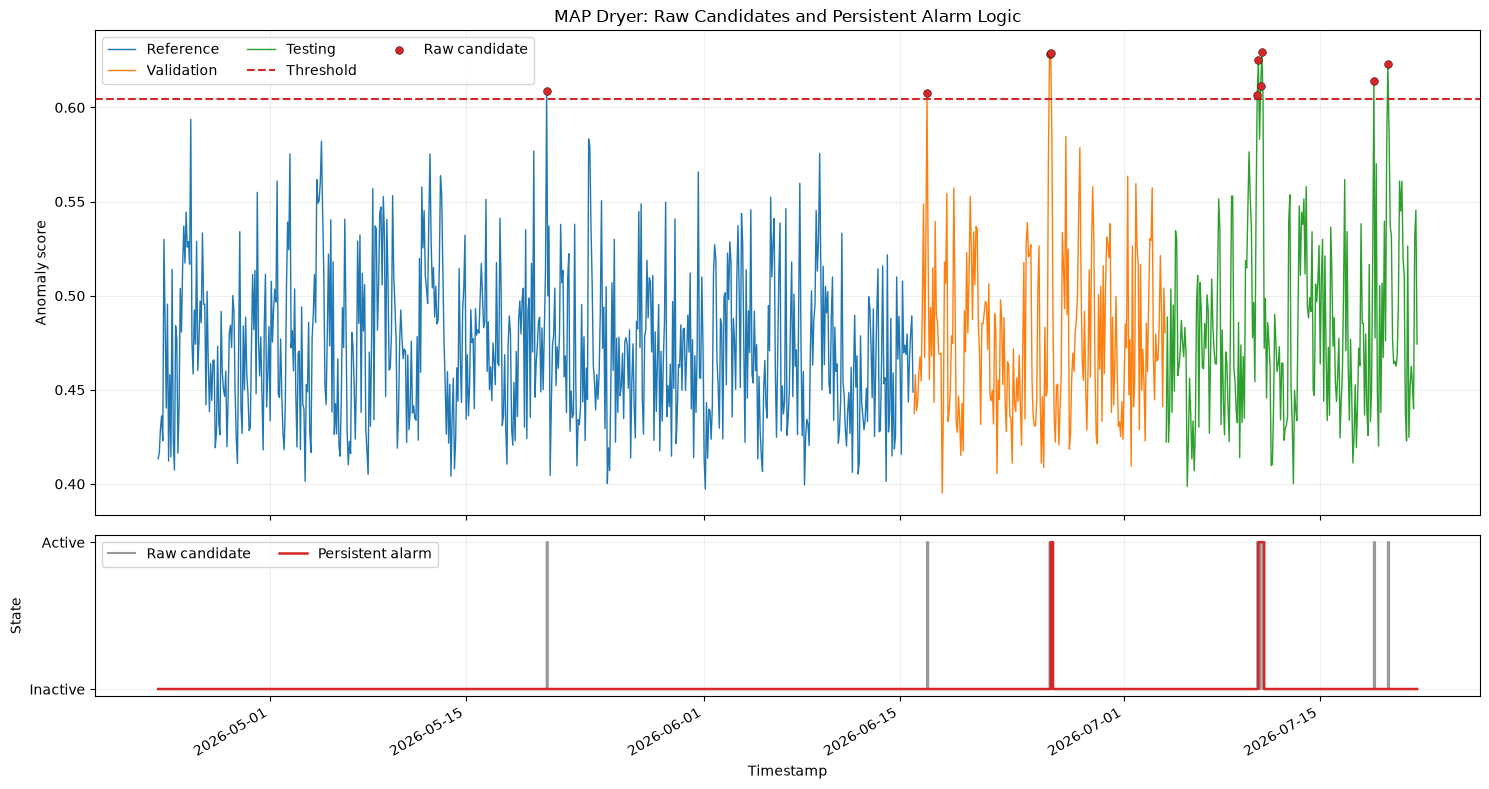

In [16]:
PERSISTENCE_WINDOW_OBSERVATIONS = 3
MINIMUM_CANDIDATES_IN_WINDOW = 2

observed_intervals = (
    anomaly_score_results["timestamp"].sort_values().diff().dropna()
)
EXPECTED_SAMPLE_INTERVAL = observed_intervals.mode().iloc[0]
if not (observed_intervals == EXPECTED_SAMPLE_INTERVAL).all():
    raise ValueError(
        "Persistence by observation count requires a regular sampling interval."
    )


def apply_persistence_logic(
    score_table,
    window_observations=PERSISTENCE_WINDOW_OBSERVATIONS,
    minimum_candidates=MINIMUM_CANDIDATES_IN_WINDOW,
):
    alarm_table = score_table.sort_values("timestamp", kind="stable").copy()
    alarm_table["Candidates in persistence window"] = (
        alarm_table["Raw anomaly flag"]
        .astype(int)
        .rolling(window=window_observations, min_periods=1)
        .sum()
        .astype(int)
    )
    alarm_table["Persistent alarm"] = (
        alarm_table["Candidates in persistence window"] >= minimum_candidates
    )
    alarm_starts = alarm_table["Persistent alarm"] & ~alarm_table[
        "Persistent alarm"
    ].shift(fill_value=False)
    alarm_numbers = alarm_starts.cumsum()
    alarm_table["Alarm episode"] = alarm_numbers.where(
        alarm_table["Persistent alarm"]
    ).astype("Int64")
    return alarm_table.reset_index(drop=True)


anomaly_score_results = apply_persistence_logic(anomaly_score_results)


def attach_pcs7_hybrid_alarm_state(score_table):
    pcs7_columns = [
        "timestamp",
        "PCS7 warning count",
        "PCS7 critical count",
        "PCS7 breach count",
        "PCS7 rule breach",
        "PCS7 breached features",
        "PCS7 limit status",
    ]
    hybrid_table = score_table.merge(
        pcs7_limit_results[pcs7_columns],
        on="timestamp",
        how="left",
        validate="one_to_one",
    )
    pcs7_critical = hybrid_table["PCS7 critical count"] > 0
    pcs7_warning = hybrid_table["PCS7 warning count"] > 0
    persistent_ml = hybrid_table["Persistent alarm"]
    raw_ml = hybrid_table["Raw anomaly flag"]

    default_state = (
        "No active alert (PCS7 limits not configured)"
        if CONFIGURED_PCS7_LIMIT_COUNT == 0
        else "Normal within configured PCS7 limits"
    )
    hybrid_table["Combined alarm state"] = np.select(
        [
            pcs7_critical & persistent_ml,
            pcs7_critical,
            pcs7_warning & persistent_ml,
            pcs7_warning,
            persistent_ml,
            raw_ml,
        ],
        [
            "Critical: PCS7 limit + persistent ML anomaly",
            "Critical: PCS7 limit",
            "High: PCS7 warning + persistent ML anomaly",
            "Warning: PCS7 limit",
            "Advisory: persistent ML anomaly",
            "Review: raw ML candidate",
        ],
        default=default_state,
    )
    hybrid_table["Combined severity level"] = np.select(
        [
            pcs7_critical & persistent_ml,
            pcs7_critical,
            pcs7_warning & persistent_ml,
            pcs7_warning,
            persistent_ml,
            raw_ml,
        ],
        [5, 5, 4, 3, 2, 1],
        default=0,
    ).astype(int)
    return hybrid_table.sort_values("timestamp", kind="stable").reset_index(drop=True)


anomaly_score_results = attach_pcs7_hybrid_alarm_state(anomaly_score_results)

persistent_alarm_rows = anomaly_score_results.loc[
    anomaly_score_results["Persistent alarm"]
]
if persistent_alarm_rows.empty:
    alarm_event_summary = pd.DataFrame(
        columns=[
            "Split",
            "Alarm start",
            "Alarm end",
            "Alarm observations",
            "Raw candidates while active",
            "Maximum anomaly score",
        ]
    )
else:
    alarm_event_summary = persistent_alarm_rows.groupby("Alarm episode").agg(
        Split=("Split", lambda values: " / ".join(pd.unique(values))),
        Alarm_start=("timestamp", "min"),
        Alarm_end=("timestamp", "max"),
        Alarm_observations=("Persistent alarm", "size"),
        Raw_candidates_while_active=("Raw anomaly flag", "sum"),
        Maximum_anomaly_score=("Anomaly score", "max"),
    )
    alarm_event_summary.columns = [
        "Split",
        "Alarm start",
        "Alarm end",
        "Alarm observations",
        "Raw candidates while active",
        "Maximum anomaly score",
    ]

hybrid_state_summary = (
    anomaly_score_results["Combined alarm state"]
    .value_counts()
    .rename_axis("Combined alarm state")
    .to_frame("Observations")
)
display(alarm_event_summary.round({"Maximum anomaly score": 5}))
display(hybrid_state_summary)
print(
    f"Persistence rule: {MINIMUM_CANDIDATES_IN_WINDOW} of "
    f"{PERSISTENCE_WINDOW_OBSERVATIONS} observations; "
    f"sample interval = {EXPECTED_SAMPLE_INTERVAL}."
)

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axes[0].plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1,
        label=split_name,
    )
axes[0].axhline(ANOMALY_THRESHOLD, color="tab:red", linestyle="--", label="Threshold")
axes[0].scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=32,
    zorder=4,
    label="Raw candidate",
)
axes[0].set_ylabel("Anomaly score")
axes[0].set_title("MAP Dryer: Raw Candidates and Persistent Alarm Logic")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left", ncol=3)

axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Raw anomaly flag"].astype(int),
    where="post",
    color="grey",
    alpha=0.8,
    label="Raw candidate",
)
axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Persistent alarm"].astype(int),
    where="post",
    color="tab:red",
    linewidth=1.8,
    label="Persistent alarm",
)
axes[1].set_yticks([0, 1], labels=["Inactive", "Active"])
axes[1].set_ylabel("State")
axes[1].set_xlabel("Timestamp")
axes[1].grid(alpha=0.2)
axes[1].legend(loc="upper left", ncol=2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "04_persistent_alarm_logic.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

### Hybrid PCS7 and machine-learning alarm timeline

Keep deterministic PCS7 rule status separate from the statistical ML signal, then combine them into a prioritized state. Critical PCS7 violations have the highest priority, followed by simultaneous PCS7 warnings and persistent ML anomalies, standalone PCS7 warnings, persistent ML advisories, and isolated raw ML candidates. Until limits are configured, the PCS7 component remains visibly disabled rather than silently treating observations as in-limit.

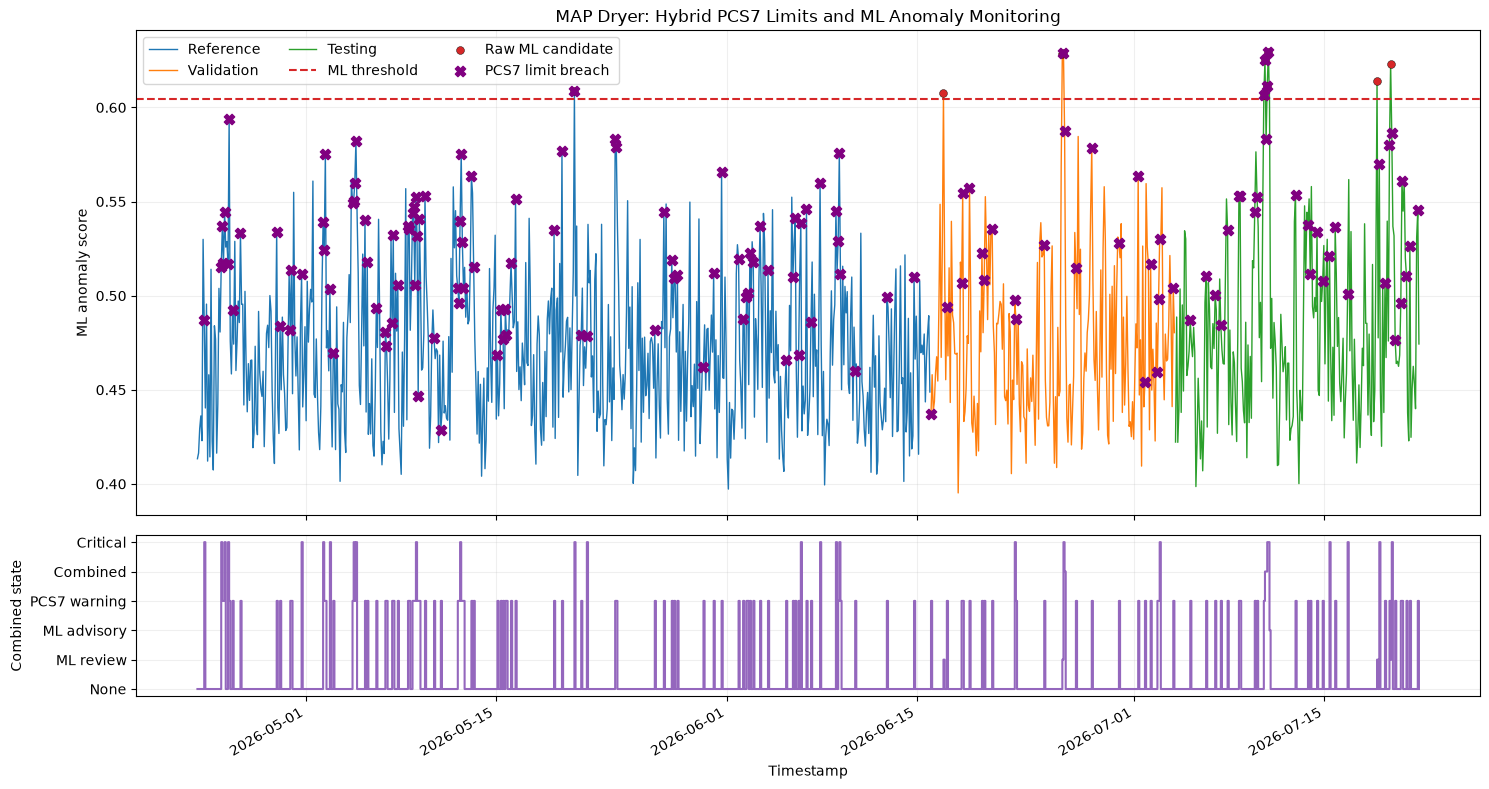

In [17]:
pcs7_breach_points = anomaly_score_results.loc[
    anomaly_score_results["PCS7 rule breach"]
]

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)
for split_name, split_color in split_colors.items():
    split_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == split_name
    ]
    axes[0].plot(
        split_scores["timestamp"],
        split_scores["Anomaly score"],
        color=split_color,
        linewidth=1,
        label=split_name,
    )
axes[0].axhline(
    ANOMALY_THRESHOLD,
    color="tab:red",
    linestyle="--",
    label="ML threshold",
)
axes[0].scatter(
    raw_anomaly_candidates["timestamp"],
    raw_anomaly_candidates["Anomaly score"],
    color="tab:red",
    edgecolor="black",
    linewidth=0.3,
    s=32,
    zorder=4,
    label="Raw ML candidate",
)
if not pcs7_breach_points.empty:
    axes[0].scatter(
        pcs7_breach_points["timestamp"],
        pcs7_breach_points["Anomaly score"],
        color="purple",
        marker="X",
        s=55,
        zorder=5,
        label="PCS7 limit breach",
    )
axes[0].set_title("MAP Dryer: Hybrid PCS7 Limits and ML Anomaly Monitoring")
axes[0].set_ylabel("ML anomaly score")
axes[0].grid(alpha=0.2)
axes[0].legend(loc="upper left", ncol=3)

axes[1].step(
    anomaly_score_results["timestamp"],
    anomaly_score_results["Combined severity level"],
    where="post",
    color="tab:purple",
    linewidth=1.5,
)
axes[1].set_yticks(
    [0, 1, 2, 3, 4, 5],
    labels=["None", "ML review", "ML advisory", "PCS7 warning", "Combined", "Critical"],
)
axes[1].set_ylabel("Combined state")
axes[1].set_xlabel("Timestamp")
axes[1].grid(alpha=0.2)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "05_hybrid_pcs7_ml_alarm_timeline.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

if CONFIGURED_PCS7_LIMIT_COUNT == 0:
    print(
        "Hybrid timeline prepared: PCS7 breach markers remain disabled until limits are configured."
    )

## 16. Evaluate the model

Confirmed anomaly labels are not available, so supervised metrics such as precision, recall, and ROC AUC cannot be reported honestly. Evaluate the baseline detector using three complementary proxies: raw and persistent alert burden by chronological split, score-distribution drift relative to the reference period, and sensitivity to controlled synthetic deviations applied only to validation features. The synthetic test shifts three measurements per validation row farther from the reference center by three standard deviations; it tests detector sensitivity, not real-world accuracy.

In [18]:
from scipy.stats import ks_2samp

split_evaluation = anomaly_score_results.groupby("Split", sort=False).agg(
    Observations=("Anomaly score", "size"),
    Median_score=("Anomaly score", "median"),
    Score_95th_percentile=("Anomaly score", lambda values: values.quantile(0.95)),
    Raw_candidates=("Raw anomaly flag", "sum"),
    Persistent_alarm_observations=("Persistent alarm", "sum"),
    Persistent_alarm_episodes=("Alarm episode", "nunique"),
)
split_evaluation["Raw candidate rate (%)"] = (
    100 * split_evaluation["Raw_candidates"] / split_evaluation["Observations"]
)
split_evaluation["Persistent alarm rate (%)"] = (
    100
    * split_evaluation["Persistent_alarm_observations"]
    / split_evaluation["Observations"]
)

reference_score_values = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Reference", "Anomaly score"
]
score_drift_rows = []
for later_split in ["Validation", "Testing"]:
    later_scores = anomaly_score_results.loc[
        anomaly_score_results["Split"] == later_split, "Anomaly score"
    ]
    drift_test = ks_2samp(reference_score_values, later_scores)
    score_drift_rows.append(
        {
            "Comparison": f"Reference vs {later_split}",
            "KS statistic": drift_test.statistic,
            "p-value": drift_test.pvalue,
            "Median score change": (
                later_scores.median() - reference_score_values.median()
            ),
        }
    )
score_drift_evaluation = pd.DataFrame(score_drift_rows).set_index("Comparison")

SYNTHETIC_FEATURES_PER_ROW = 3
SYNTHETIC_SHIFT_STANDARD_DEVIATIONS = 3.0
synthetic_rng = np.random.default_rng(42)
synthetic_validation_values = X_validation_scaled.to_numpy(copy=True)
for row_index in range(len(synthetic_validation_values)):
    shifted_feature_indices = synthetic_rng.choice(
        len(MODEL_FEATURES),
        size=SYNTHETIC_FEATURES_PER_ROW,
        replace=False,
    )
    original_values = synthetic_validation_values[
        row_index, shifted_feature_indices
    ]
    outward_directions = np.where(original_values >= 0, 1.0, -1.0)
    synthetic_validation_values[row_index, shifted_feature_indices] += (
        outward_directions * SYNTHETIC_SHIFT_STANDARD_DEVIATIONS
    )

X_validation_synthetic_scaled = pd.DataFrame(
    synthetic_validation_values,
    columns=MODEL_FEATURES,
    index=X_validation_scaled.index,
)
synthetic_validation_scores = -isolation_forest_model.score_samples(
    X_validation_synthetic_scaled
)
baseline_synthetic_detection_rate = float(
    np.mean(synthetic_validation_scores >= ANOMALY_THRESHOLD)
)

baseline_evaluation_summary = pd.Series(
    {
        "Validation raw candidate rate (%)": split_evaluation.loc[
            "Validation", "Raw candidate rate (%)"
        ],
        "Validation persistent alarm episodes": split_evaluation.loc[
            "Validation", "Persistent_alarm_episodes"
        ],
        "Synthetic validation detection rate (%)": (
            100 * baseline_synthetic_detection_rate
        ),
        "Test raw candidate rate (%) - descriptive only": split_evaluation.loc[
            "Testing", "Raw candidate rate (%)"
        ],
        "Test persistent alarm episodes - descriptive only": split_evaluation.loc[
            "Testing", "Persistent_alarm_episodes"
        ],
    },
    name="Baseline Isolation Forest",
)

if CONFIGURED_PCS7_LIMIT_COUNT > 0:
    pcs7_breach_mask = anomaly_score_results["PCS7 rule breach"]
    pcs7_breach_count = int(pcs7_breach_mask.sum())
    pcs7_ml_agreement = pd.crosstab(
        anomaly_score_results["PCS7 limit status"],
        anomaly_score_results["Persistent alarm"],
        rownames=["PCS7 status"],
        colnames=["Persistent ML alarm"],
    )
    pcs7_ml_comparison = pd.Series(
        {
            "Configured PCS7 limit breaches": pcs7_breach_count,
            "PCS7 breaches also detected as raw ML candidates (%)": (
                100
                * anomaly_score_results.loc[pcs7_breach_mask, "Raw anomaly flag"].mean()
                if pcs7_breach_count
                else np.nan
            ),
            "PCS7 breaches also detected as persistent ML alarms (%)": (
                100
                * anomaly_score_results.loc[pcs7_breach_mask, "Persistent alarm"].mean()
                if pcs7_breach_count
                else np.nan
            ),
            "Raw ML candidates without a PCS7 breach": int(
                (
                    anomaly_score_results["Raw anomaly flag"]
                    & ~pcs7_breach_mask
                ).sum()
            ),
        },
        name="PCS7 and ML comparison",
    )
else:
    pcs7_ml_agreement = pd.DataFrame(
        {
            "Status": [
                "Unavailable until at least one approved PCS7 limit is configured."
            ]
        }
    )
    pcs7_ml_comparison = pd.Series(
        {"Configured PCS7 limits": 0},
        name="PCS7 and ML comparison",
    )

display(split_evaluation.round(4))
display(score_drift_evaluation.round(5))
display(baseline_evaluation_summary.to_frame().round(4))
display(pcs7_ml_agreement)
display(pcs7_ml_comparison.to_frame().round(4))
print(
    "Evaluation is label-free: alert rates and synthetic sensitivity are proxies, "
    "not estimates of real anomaly-detection accuracy."
)

,Observations,Median_score,Score_95th_percentile,Raw_candidates,Persistent_alarm_observations,Persistent_alarm_episodes,Raw candidate rate (%),Persistent alarm rate (%)
Split,,,,,,,,
Reference,648,0.4695,0.5450,1,0,0,0.1543,0.0000
Validation,216,0.4694,0.5572,3,2,1,1.3889,0.9259
Testing,216,0.4724,0.5717,6,5,1,2.7778,2.3148


,KS statistic,p-value,Median score change
Comparison,,,
Reference vs Validation,0.08179,0.22262,-0.00016
Reference vs Testing,0.10340,0.06041,0.00283


,Baseline Isolation Forest
Validation raw candidate rate (%),1.3889
Validation persistent alarm episodes,1.0000
Synthetic validation detection rate (%),3.7037
Test raw candidate rate (%) - descriptive only,2.7778
Test persistent alarm episodes - descriptive only,1.0000


Persistent ML alarm,False,True
PCS7 status,,
Critical,23,3
Warning,122,3
Within configured limits,928,1


,PCS7 and ML comparison
Configured PCS7 limit breaches,151.0000
PCS7 breaches also detected as raw ML candidates (%),3.9735
PCS7 breaches also detected as persistent ML alarms (%),3.9735
Raw ML candidates without a PCS7 breach,4.0000


Evaluation is label-free: alert rates and synthetic sensitivity are proxies, not estimates of real anomaly-detection accuracy.


## 17. Tune Isolation Forest hyperparameters

Tune the number of trees, samples per tree, and fraction of features per tree. Every candidate is fitted only on the normal reference period and calibrated with the validation 99th-percentile threshold. Rank configurations by synthetic validation sensitivity, then by lower reference candidate rate and stronger score agreement with the baseline model. The test period is not used to select the configuration. Synthetic deviations are only a reproducible tuning proxy, so the selected parameters still require confirmation with real event labels when those become available.

In [19]:
from itertools import product
from scipy.stats import spearmanr

ISOLATION_FOREST_TUNING_GRID = {
    "n_estimators": [200, 300, 500],
    "max_samples": [128, 256, min(512, len(X_normal_reference_scaled))],
    "max_features": [0.75, 1.0],
}

baseline_validation_score_values = anomaly_score_results.loc[
    anomaly_score_results["Split"] == "Validation", "Anomaly score"
].to_numpy()

tuning_rows = []
for n_estimators, max_samples, max_features in product(
    ISOLATION_FOREST_TUNING_GRID["n_estimators"],
    ISOLATION_FOREST_TUNING_GRID["max_samples"],
    ISOLATION_FOREST_TUNING_GRID["max_features"],
):
    candidate_model = IsolationForest(
        n_estimators=n_estimators,
        max_samples=max_samples,
        contamination="auto",
        max_features=max_features,
        bootstrap=False,
        random_state=42,
        n_jobs=-1,
    )
    candidate_model.fit(X_normal_reference_scaled)

    candidate_reference_scores = -candidate_model.score_samples(
        X_normal_reference_scaled
    )
    candidate_validation_scores = -candidate_model.score_samples(
        X_validation_scaled
    )
    candidate_synthetic_scores = -candidate_model.score_samples(
        X_validation_synthetic_scaled
    )
    candidate_threshold = float(
        pd.Series(candidate_validation_scores).quantile(
            VALIDATION_THRESHOLD_QUANTILE
        )
    )
    score_stability = spearmanr(
        baseline_validation_score_values, candidate_validation_scores
    ).statistic

    tuning_rows.append(
        {
            "n_estimators": n_estimators,
            "max_samples": max_samples,
            "max_features": max_features,
            "Validation threshold": candidate_threshold,
            "Reference candidate rate (%)": (
                100 * np.mean(candidate_reference_scores >= candidate_threshold)
            ),
            "Validation candidate rate (%)": (
                100 * np.mean(candidate_validation_scores >= candidate_threshold)
            ),
            "Synthetic detection rate (%)": (
                100 * np.mean(candidate_synthetic_scores >= candidate_threshold)
            ),
            "Score stability vs baseline": score_stability,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(
        [
            "Synthetic detection rate (%)",
            "Reference candidate rate (%)",
            "Score stability vs baseline",
            "n_estimators",
        ],
        ascending=[False, True, False, True],
    )
    .reset_index(drop=True)
)

best_tuning_row = tuning_results.iloc[0]
best_isolation_forest_parameters = {
    "n_estimators": int(best_tuning_row["n_estimators"]),
    "max_samples": int(best_tuning_row["max_samples"]),
    "max_features": float(best_tuning_row["max_features"]),
}

selected_isolation_forest_model = IsolationForest(
    **best_isolation_forest_parameters,
    contamination="auto",
    bootstrap=False,
    random_state=42,
    n_jobs=-1,
)
selected_isolation_forest_model.fit(X_normal_reference_scaled)


def build_selected_score_table(split_name, timestamps, scaled_features):
    return pd.DataFrame(
        {
            "timestamp": timestamps.to_numpy(),
            "Split": split_name,
            "Anomaly score": -selected_isolation_forest_model.score_samples(
                scaled_features[MODEL_FEATURES]
            ),
        }
    )


selected_anomaly_score_results = (
    pd.concat(
        [
            build_selected_score_table(
                "Reference", train_timestamps, X_train_scaled
            ),
            build_selected_score_table(
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_selected_score_table(
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

selected_validation_scores = selected_anomaly_score_results.loc[
    selected_anomaly_score_results["Split"] == "Validation",
    "Anomaly score",
]
SELECTED_ANOMALY_THRESHOLD = float(
    selected_validation_scores.quantile(VALIDATION_THRESHOLD_QUANTILE)
)
selected_anomaly_score_results["Raw anomaly flag"] = (
    selected_anomaly_score_results["Anomaly score"]
    >= SELECTED_ANOMALY_THRESHOLD
)
selected_anomaly_score_results = apply_persistence_logic(
    selected_anomaly_score_results
)
selected_anomaly_score_results = attach_pcs7_hybrid_alarm_state(
    selected_anomaly_score_results
)

selected_synthetic_scores = -selected_isolation_forest_model.score_samples(
    X_validation_synthetic_scaled
)
selected_synthetic_detection_rate = float(
    np.mean(selected_synthetic_scores >= SELECTED_ANOMALY_THRESHOLD)
)

def candidate_rate(score_table, split_name):
    split_rows = score_table.loc[score_table["Split"] == split_name]
    return 100 * split_rows["Raw anomaly flag"].mean()


baseline_vs_selected_comparison = pd.DataFrame(
    {
        "Baseline Isolation Forest": {
            "Trees": isolation_forest_model.n_estimators,
            "Maximum samples": isolation_forest_model.max_samples_,
            "Maximum feature fraction": isolation_forest_model.max_features,
            "Validation threshold": ANOMALY_THRESHOLD,
            "Reference candidate rate (%)": candidate_rate(
                anomaly_score_results, "Reference"
            ),
            "Validation candidate rate (%)": candidate_rate(
                anomaly_score_results, "Validation"
            ),
            "Synthetic detection rate (%)": (
                100 * baseline_synthetic_detection_rate
            ),
        },
        "Selected Isolation Forest": {
            "Trees": selected_isolation_forest_model.n_estimators,
            "Maximum samples": selected_isolation_forest_model.max_samples_,
            "Maximum feature fraction": selected_isolation_forest_model.max_features,
            "Validation threshold": SELECTED_ANOMALY_THRESHOLD,
            "Reference candidate rate (%)": candidate_rate(
                selected_anomaly_score_results, "Reference"
            ),
            "Validation candidate rate (%)": candidate_rate(
                selected_anomaly_score_results, "Validation"
            ),
            "Synthetic detection rate (%)": (
                100 * selected_synthetic_detection_rate
            ),
        },
    }
)

display(tuning_results.round(5))
display(baseline_vs_selected_comparison.round(5))
print("Selected parameters:", best_isolation_forest_parameters)
print(f"Selected validation threshold: {SELECTED_ANOMALY_THRESHOLD:.5f}")
print("The test period was not used to rank or select hyperparameters.")

,n_estimators,max_samples,max_features,Validation threshold,Reference candidate rate (%),Validation candidate rate (%),Synthetic detection rate (%),Score stability vs baseline
0,200,512,1.00,0.58362,0.0,1.38889,8.79630,0.97690
1,200,256,0.75,0.58986,0.0,1.38889,7.87037,0.97457
2,300,512,1.00,0.58923,0.0,1.38889,6.94444,0.98336
3,300,512,0.75,0.58831,0.0,1.38889,6.94444,0.98258
4,200,512,0.75,0.59273,0.0,1.38889,6.94444,0.97750
5,500,512,1.00,0.59051,0.0,1.38889,6.48148,0.98657
6,500,512,0.75,0.59339,0.0,1.38889,6.48148,0.98467
7,300,256,0.75,0.59018,0.0,1.38889,6.48148,0.98113
8,500,256,0.75,0.59014,0.0,1.38889,6.01852,0.98637
9,300,128,0.75,0.59020,0.0,1.38889,6.01852,0.98097


,Baseline Isolation Forest,Selected Isolation Forest
Trees,300.00000,200.00000
Maximum samples,256.00000,512.00000
Maximum feature fraction,1.00000,1.00000
Validation threshold,0.60469,0.58362
Reference candidate rate (%),0.15432,0.30864
Validation candidate rate (%),1.38889,1.38889
Synthetic detection rate (%),3.70370,8.79630


Selected parameters: {'n_estimators': 200, 'max_samples': 512, 'max_features': 1.0}
Selected validation threshold: 0.58362
The test period was not used to rank or select hyperparameters.


## 18. Compare with another detector

Compare the selected Isolation Forest with an RBF One-Class SVM, a boundary-based anomaly detector that provides a meaningfully different modelling approach. Fit both detectors on the same scaled normal reference period, calibrate each model independently at its validation 99th percentile, apply the same synthetic stress and 2-of-3 persistence rules, and keep the test results descriptive. Because confirmed event labels are unavailable, the comparison measures operational behaviour and proxy sensitivity rather than real precision or recall.

,Validation threshold,Reference candidate rate (%),Validation candidate rate (%),Validation persistent episodes,Synthetic detection rate (%),Test candidate rate (%) - descriptive,Test persistent episodes - descriptive
Detector,,,,,,,
Selected Isolation Forest,0.58362,0.30864,1.38889,1,8.7963,3.70370,2
One-Class SVM,-0.25064,1.08025,1.38889,0,100.0000,4.62963,3


Agreement category,Both detectors,Isolation Forest only,Neither detector,One-Class SVM only
Split,,,,
Reference,1,1,640,6
Testing,7,1,205,3
Validation,2,1,212,1


Validation score-rank correlation: 0.948
One-Class SVM is retained as a challenger; real labeled events are required before replacing the selected Isolation Forest.


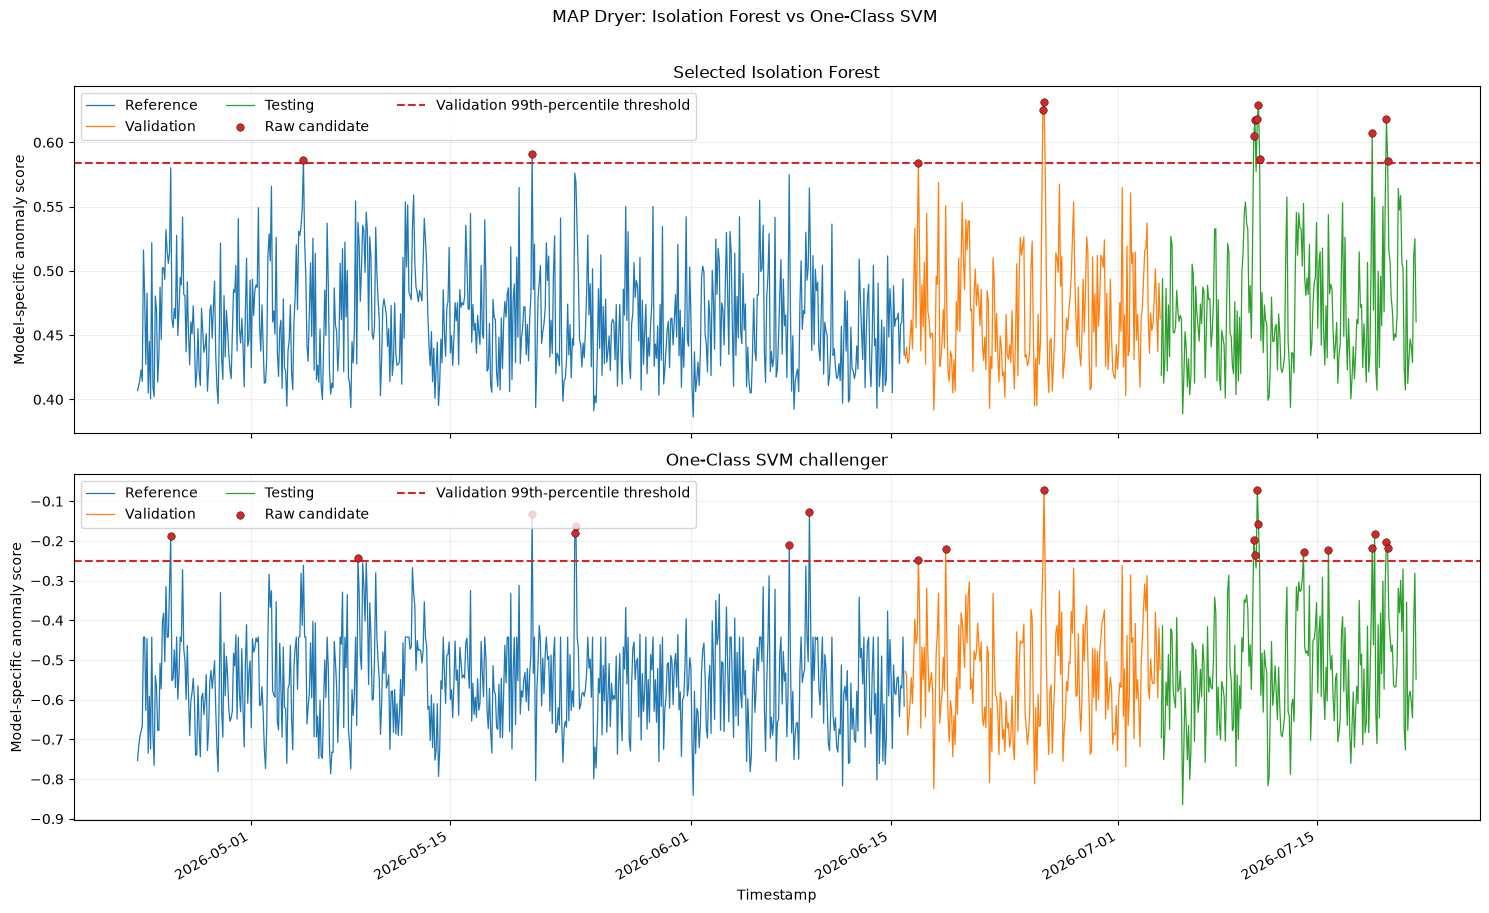

In [20]:
from sklearn.svm import OneClassSVM

one_class_svm_model = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.01,
)
one_class_svm_model.fit(X_normal_reference_scaled)


def build_one_class_svm_score_table(split_name, timestamps, scaled_features):
    return pd.DataFrame(
        {
            "timestamp": timestamps.to_numpy(),
            "Split": split_name,
            "Anomaly score": -one_class_svm_model.score_samples(
                scaled_features[MODEL_FEATURES]
            ),
        }
    )


one_class_svm_score_results = (
    pd.concat(
        [
            build_one_class_svm_score_table(
                "Reference", train_timestamps, X_train_scaled
            ),
            build_one_class_svm_score_table(
                "Validation", validation_timestamps, X_validation_scaled
            ),
            build_one_class_svm_score_table(
                "Testing", test_timestamps, X_test_scaled
            ),
        ],
        ignore_index=True,
    )
    .sort_values("timestamp", kind="stable")
    .reset_index(drop=True)
)

one_class_svm_validation_scores = one_class_svm_score_results.loc[
    one_class_svm_score_results["Split"] == "Validation",
    "Anomaly score",
]
ONE_CLASS_SVM_THRESHOLD = float(
    one_class_svm_validation_scores.quantile(VALIDATION_THRESHOLD_QUANTILE)
)
one_class_svm_score_results["Raw anomaly flag"] = (
    one_class_svm_score_results["Anomaly score"] >= ONE_CLASS_SVM_THRESHOLD
)
one_class_svm_score_results = apply_persistence_logic(
    one_class_svm_score_results
)
one_class_svm_score_results = attach_pcs7_hybrid_alarm_state(
    one_class_svm_score_results
)

one_class_svm_synthetic_scores = -one_class_svm_model.score_samples(
    X_validation_synthetic_scaled
)
one_class_svm_synthetic_detection_rate = float(
    np.mean(one_class_svm_synthetic_scores >= ONE_CLASS_SVM_THRESHOLD)
)


def detector_comparison_row(
    detector_name, score_table, threshold, synthetic_detection_rate
):
    split_tables = {
        split_name: score_table.loc[score_table["Split"] == split_name]
        for split_name in ["Reference", "Validation", "Testing"]
    }
    return {
        "Detector": detector_name,
        "Validation threshold": threshold,
        "Reference candidate rate (%)": (
            100 * split_tables["Reference"]["Raw anomaly flag"].mean()
        ),
        "Validation candidate rate (%)": (
            100 * split_tables["Validation"]["Raw anomaly flag"].mean()
        ),
        "Validation persistent episodes": split_tables["Validation"][
            "Alarm episode"
        ].nunique(),
        "Synthetic detection rate (%)": 100 * synthetic_detection_rate,
        "Test candidate rate (%) - descriptive": (
            100 * split_tables["Testing"]["Raw anomaly flag"].mean()
        ),
        "Test persistent episodes - descriptive": split_tables["Testing"][
            "Alarm episode"
        ].nunique(),
    }


detector_comparison = pd.DataFrame(
    [
        detector_comparison_row(
            "Selected Isolation Forest",
            selected_anomaly_score_results,
            SELECTED_ANOMALY_THRESHOLD,
            selected_synthetic_detection_rate,
        ),
        detector_comparison_row(
            "One-Class SVM",
            one_class_svm_score_results,
            ONE_CLASS_SVM_THRESHOLD,
            one_class_svm_synthetic_detection_rate,
        ),
    ]
).set_index("Detector")

detector_flag_agreement = (
    selected_anomaly_score_results[
        ["timestamp", "Split", "Raw anomaly flag"]
    ]
    .rename(columns={"Raw anomaly flag": "Isolation Forest flag"})
    .merge(
        one_class_svm_score_results[
            ["timestamp", "Raw anomaly flag"]
        ].rename(columns={"Raw anomaly flag": "One-Class SVM flag"}),
        on="timestamp",
        how="inner",
        validate="one_to_one",
    )
)
detector_flag_agreement["Agreement category"] = np.select(
    [
        detector_flag_agreement["Isolation Forest flag"]
        & detector_flag_agreement["One-Class SVM flag"],
        detector_flag_agreement["Isolation Forest flag"],
        detector_flag_agreement["One-Class SVM flag"],
    ],
    ["Both detectors", "Isolation Forest only", "One-Class SVM only"],
    default="Neither detector",
)
detector_agreement_summary = pd.crosstab(
    detector_flag_agreement["Split"],
    detector_flag_agreement["Agreement category"],
)

validation_score_comparison = (
    selected_anomaly_score_results.loc[
        selected_anomaly_score_results["Split"] == "Validation",
        ["timestamp", "Anomaly score"],
    ]
    .rename(columns={"Anomaly score": "Isolation Forest score"})
    .merge(
        one_class_svm_score_results.loc[
            one_class_svm_score_results["Split"] == "Validation",
            ["timestamp", "Anomaly score"],
        ].rename(columns={"Anomaly score": "One-Class SVM score"}),
        on="timestamp",
        validate="one_to_one",
    )
)
detector_validation_rank_correlation = spearmanr(
    validation_score_comparison["Isolation Forest score"],
    validation_score_comparison["One-Class SVM score"],
).statistic

display(detector_comparison.round(5))
display(detector_agreement_summary)
print(
    f"Validation score-rank correlation: "
    f"{detector_validation_rank_correlation:.3f}"
)
print(
    "One-Class SVM is retained as a challenger; real labeled events are required "
    "before replacing the selected Isolation Forest."
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
detector_plot_settings = [
    (
        axes[0],
        selected_anomaly_score_results,
        SELECTED_ANOMALY_THRESHOLD,
        "Selected Isolation Forest",
    ),
    (
        axes[1],
        one_class_svm_score_results,
        ONE_CLASS_SVM_THRESHOLD,
        "One-Class SVM challenger",
    ),
]
for axis, score_table, threshold, detector_title in detector_plot_settings:
    for split_name, split_color in split_colors.items():
        split_scores = score_table.loc[score_table["Split"] == split_name]
        axis.plot(
            split_scores["timestamp"],
            split_scores["Anomaly score"],
            color=split_color,
            linewidth=0.9,
            label=split_name,
        )
    detector_candidates = score_table.loc[score_table["Raw anomaly flag"]]
    axis.scatter(
        detector_candidates["timestamp"],
        detector_candidates["Anomaly score"],
        color="tab:red",
        edgecolor="black",
        linewidth=0.3,
        s=30,
        zorder=4,
        label="Raw candidate",
    )
    axis.axhline(
        threshold,
        color="tab:red",
        linestyle="--",
        label="Validation 99th-percentile threshold",
    )
    axis.set_title(detector_title)
    axis.set_ylabel("Model-specific anomaly score")
    axis.grid(alpha=0.2)
    axis.legend(loc="upper left", ncol=3)

axes[1].set_xlabel("Timestamp")
fig.suptitle("MAP Dryer: Isolation Forest vs One-Class SVM", y=1.01)
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig(
    FIGURE_OUTPUT_DIR / "06_isolation_forest_vs_one_class_svm.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Next task

Task 19 will save the selected Isolation Forest, fitted scaler, selected threshold, feature order, PCS7 limit configuration, and persistence settings as one deployable artifact bundle.